In [65]:
import pandas as pd
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score

In [66]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [67]:
df=pd.read_csv('C:\Padhma\GUVI\CCT\projects\patroliq-main\patroliq-main\PatrolIQ_cleaned.csv')
df.head()

<>:1: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
<>:1: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
C:\Users\rsrin\AppData\Local\Temp\ipykernel_17664\1991321068.py:1: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
  df=pd.read_csv('C:\Padhma\GUVI\CCT\projects\patroliq-main\patroliq-main\PatrolIQ_cleaned.csv')


,Unnamed: 0,Arrest,Domestic,Beat,District,Ward,Community Area,Year,Latitude,Longitude,Hour,Month,Is_Weekend,Day_enc,primary_Arson,primary_Assault,primary_Battery,primary_Burglary,primary_Concealed Carry License Violation,primary_Crim Sexual Assault,primary_Criminal Damage,primary_Criminal Sexual Assault,primary_Criminal Trespass,primary_Deceptive Practice,primary_Gambling,primary_Homicide,primary_Human Trafficking,primary_Interference With Public Officer,primary_Intimidation,primary_Kidnapping,primary_Liquor Law Violation,primary_Motor Vehicle Theft,primary_Narcotics,primary_Non-Criminal,primary_Obscenity,primary_Offense Involving Children,primary_Other Narcotic Violation,primary_Other Offense,primary_Prostitution,primary_Public Indecency,primary_Public Peace Violation,primary_Ritualism,primary_Robbery,primary_Sex Offense,primary_Stalking,primary_Theft,primary_Weapons Violation,location_freq
0,0,0,0,1724,17.0,33.0,14.0,2025,41.962967,-87.712351,12,12,0,3,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.348900
1,1,1,1,1533,15.0,28.0,25.0,2025,41.879492,-87.745999,0,12,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0.348900
2,2,0,1,1231,12.0,28.0,28.0,2025,41.868220,-87.664047,0,12,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0.348900
3,3,1,0,1911,19.0,47.0,4.0,2025,41.962324,-87.684443,12,12,0,3,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.158418
4,4,1,0,2422,24.0,49.0,1.0,2025,42.018696,-87.673058,12,12,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0.346946


In [68]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [69]:
df.head()

,Arrest,Domestic,Beat,District,Ward,Community Area,Year,Latitude,Longitude,Hour,Month,Is_Weekend,Day_enc,primary_Arson,primary_Assault,primary_Battery,primary_Burglary,primary_Concealed Carry License Violation,primary_Crim Sexual Assault,primary_Criminal Damage,primary_Criminal Sexual Assault,primary_Criminal Trespass,primary_Deceptive Practice,primary_Gambling,primary_Homicide,primary_Human Trafficking,primary_Interference With Public Officer,primary_Intimidation,primary_Kidnapping,primary_Liquor Law Violation,primary_Motor Vehicle Theft,primary_Narcotics,primary_Non-Criminal,primary_Obscenity,primary_Offense Involving Children,primary_Other Narcotic Violation,primary_Other Offense,primary_Prostitution,primary_Public Indecency,primary_Public Peace Violation,primary_Ritualism,primary_Robbery,primary_Sex Offense,primary_Stalking,primary_Theft,primary_Weapons Violation,location_freq
0,0,0,1724,17.0,33.0,14.0,2025,41.962967,-87.712351,12,12,0,3,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.348900
1,1,1,1533,15.0,28.0,25.0,2025,41.879492,-87.745999,0,12,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0.348900
2,0,1,1231,12.0,28.0,28.0,2025,41.868220,-87.664047,0,12,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0.348900
3,1,0,1911,19.0,47.0,4.0,2025,41.962324,-87.684443,12,12,0,3,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.158418
4,1,0,2422,24.0,49.0,1.0,2025,42.018696,-87.673058,12,12,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0.346946


In [70]:
df.columns.to_list()

['Arrest',
 'Domestic',
 'Beat',
 'District',
 'Ward',
 'Community Area',
 'Year',
 'Latitude',
 'Longitude',
 'Hour',
 'Month',
 'Is_Weekend',
 'Day_enc',
 'primary_Arson',
 'primary_Assault',
 'primary_Battery',
 'primary_Burglary',
 'primary_Concealed Carry License Violation',
 'primary_Crim Sexual Assault',
 'primary_Criminal Damage',
 'primary_Criminal Sexual Assault',
 'primary_Criminal Trespass',
 'primary_Deceptive Practice',
 'primary_Gambling',
 'primary_Homicide',
 'primary_Human Trafficking',
 'primary_Interference With Public Officer',
 'primary_Intimidation',
 'primary_Kidnapping',
 'primary_Liquor Law Violation',
 'primary_Motor Vehicle Theft',
 'primary_Narcotics',
 'primary_Non-Criminal',
 'primary_Obscenity',
 'primary_Offense Involving Children',
 'primary_Other Narcotic Violation',
 'primary_Other Offense',
 'primary_Prostitution',
 'primary_Public Indecency',
 'primary_Public Peace Violation',
 'primary_Ritualism',
 'primary_Robbery',
 'primary_Sex Offense',
 'prim

In [71]:
lat_min, lat_max = 41.6, 42.1
lon_min, lon_max = -88.0, -87.5

In [72]:
df_clean = df[
    df['Latitude'].between(lat_min, lat_max) &
    df['Longitude'].between(lon_min, lon_max)
].copy()


K-MEANS CLSTERING

In [73]:
features = [
    'Latitude', 'Longitude',
    'Hour', 'Is_Weekend',
    'location_freq'
]
KM_features=['Latitude', 'Longitude']

X = df_clean[features]
KM_X=df_clean[KM_features]


In [74]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
KM_X_scaled = scaler.fit_transform(KM_X)


ELBOW METHOD

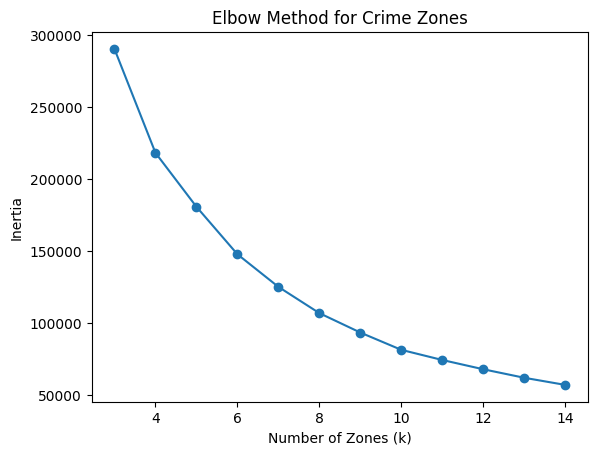

In [75]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(3, 15):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(KM_X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(3, 15), inertia, marker='o')
plt.xlabel("Number of Zones (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Crime Zones")
plt.show()


In [76]:
k = 10  
kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=20
)

df_clean['crime_zone'] = kmeans.fit_predict(KM_X_scaled)


In [77]:
labels = df_clean['crime_zone'].values
print(KM_X_scaled.shape[0], len(labels))


462592 462592


In [78]:
centroids_scaled = kmeans.cluster_centers_
centroids = scaler.inverse_transform(centroids_scaled)

centroids_df = pd.DataFrame(
    centroids,
    columns=KM_features
)[['Latitude', 'Longitude']]


In [79]:
print(df_clean.columns)


Index(['Arrest', 'Domestic', 'Beat', 'District', 'Ward', 'Community Area',
       'Year', 'Latitude', 'Longitude', 'Hour', 'Month', 'Is_Weekend',
       'Day_enc', 'primary_Arson', 'primary_Assault', 'primary_Battery',
       'primary_Burglary', 'primary_Concealed Carry License Violation',
       'primary_Crim Sexual Assault', 'primary_Criminal Damage',
       'primary_Criminal Sexual Assault', 'primary_Criminal Trespass',
       'primary_Deceptive Practice', 'primary_Gambling', 'primary_Homicide',
       'primary_Human Trafficking', 'primary_Interference With Public Officer',
       'primary_Intimidation', 'primary_Kidnapping',
       'primary_Liquor Law Violation', 'primary_Motor Vehicle Theft',
       'primary_Narcotics', 'primary_Non-Criminal', 'primary_Obscenity',
       'primary_Offense Involving Children',
       'primary_Other Narcotic Violation', 'primary_Other Offense',
       'primary_Prostitution', 'primary_Public Indecency',
       'primary_Public Peace Violation', 'primar

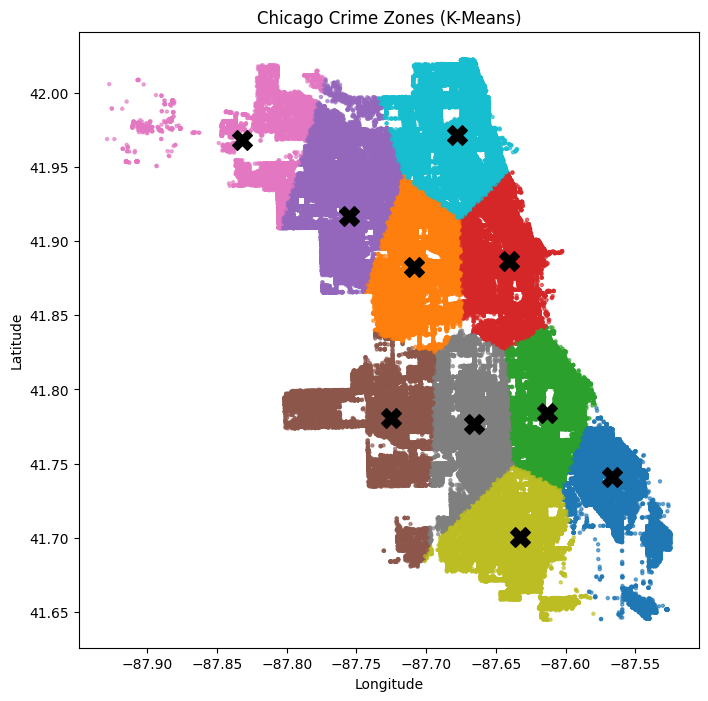

In [80]:
plt.figure(figsize=(8, 8))
plt.scatter(
    df_clean['Longitude'],
    df_clean['Latitude'],
    c=df_clean['crime_zone'],
    cmap='tab10',
    s=5,
    alpha=0.6
)
plt.scatter(
    centroids_df['Longitude'],
    centroids_df['Latitude'],
    c='black',
    s=200,
    marker='X'
)
plt.title("Chicago Crime Zones (K-Means)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


In [81]:
import joblib
joblib.dump(
    {
        "model": kmeans,
        "scaler": scaler,
        "features": features
    },
    "C:\\Padhma\\GUVI\\CCT\\projects\\patroliq-main\\patroliq-main\\crime_zone_kmeans_bundle.pkl"
)


['C:\\Padhma\\GUVI\\CCT\\projects\\patroliq-main\\patroliq-main\\crime_zone_kmeans_bundle.pkl']

#DBSCAN


In [82]:
df_clean.isnull().sum()
df_clean.shape
df_clean.dropna(inplace=True)

In [83]:
df_clean.shape

(462591, 48)

In [84]:
df_clean.to_csv("C:\\Padhma\\GUVI\\CCT\\projects\\patroliq-main\\patroliq-main\\cluster_data.csv")

In [85]:

df0=pd.read_csv("C:\\Padhma\\GUVI\\CCT\\projects\\patroliq-main\\patroliq-main\\cluster_data.csv")

In [86]:

df0.drop(columns=['Unnamed: 0'], inplace=True)


In [87]:
df0.head()

,Arrest,Domestic,Beat,District,Ward,Community Area,Year,Latitude,Longitude,Hour,Month,Is_Weekend,Day_enc,primary_Arson,primary_Assault,primary_Battery,primary_Burglary,primary_Concealed Carry License Violation,primary_Crim Sexual Assault,primary_Criminal Damage,primary_Criminal Sexual Assault,primary_Criminal Trespass,primary_Deceptive Practice,primary_Gambling,primary_Homicide,primary_Human Trafficking,primary_Interference With Public Officer,primary_Intimidation,primary_Kidnapping,primary_Liquor Law Violation,primary_Motor Vehicle Theft,primary_Narcotics,primary_Non-Criminal,primary_Obscenity,primary_Offense Involving Children,primary_Other Narcotic Violation,primary_Other Offense,primary_Prostitution,primary_Public Indecency,primary_Public Peace Violation,primary_Ritualism,primary_Robbery,primary_Sex Offense,primary_Stalking,primary_Theft,primary_Weapons Violation,location_freq,crime_zone
0,0,0,1724,17.0,33.0,14.0,2025,41.962967,-87.712351,12,12,0,3,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.348900,9
1,1,1,1533,15.0,28.0,25.0,2025,41.879492,-87.745999,0,12,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0.348900,4
2,0,1,1231,12.0,28.0,28.0,2025,41.868220,-87.664047,0,12,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0.348900,3
3,1,0,1911,19.0,47.0,4.0,2025,41.962324,-87.684443,12,12,0,3,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.158418,9
4,1,0,2422,24.0,49.0,1.0,2025,42.018696,-87.673058,12,12,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0.346946,9


In [88]:
df_sample = df0.sample(100_000, random_state=42)


In [89]:
Y = df_sample[['Latitude', 'Longitude']].dropna()
df_db = df0.loc[Y.index].copy()

In [90]:
from sklearn.preprocessing import StandardScaler

Y_scaled = StandardScaler().fit_transform(Y)


In [91]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.04,        # for scaled data
    min_samples=80,
    n_jobs=-1        # use all cores
)

df_db['dbscan_cluster'] = dbscan.fit_predict(Y_scaled)


In [92]:
df_db.value_counts('dbscan_cluster')

dbscan_cluster
-1     34210
 3     15158
 0     14583
 6      8554
 2      4932
 4      4703
 11     2190
 18     1474
 14     1155
 1      1024
 8       619
 24      600
 34      598
 29      562
 25      519
 28      435
 37      388
 12      319
 32      293
 15      274
 10      269
 16      255
 22      241
 38      240
 33      223
 5       214
 39      206
 19      191
 36      190
 20      188
 51      187
 21      185
 13      175
 30      158
 40      158
 27      152
 43      149
 50      148
 44      143
 49      138
 58      138
 72      137
 48      133
 57      130
 9       129
 35      125
 41      125
 42      124
 7       123
 26      123
 63      119
 23      116
 45      116
 46      115
 17      115
 47      114
 31      106
 60      106
 56       98
 53       86
 55       84
 67       84
 61       84
 52       83
 64       82
 71       80
 59       80
 69       74
 70       73
 68       73
 74       73
 65       69
 66       65
 54       59
 75       57
 73       

In [93]:
noise_pct = (df_db['dbscan_cluster'] == -1).mean() * 100
print(f"Noise: {noise_pct:.2f}%")


Noise: 34.21%


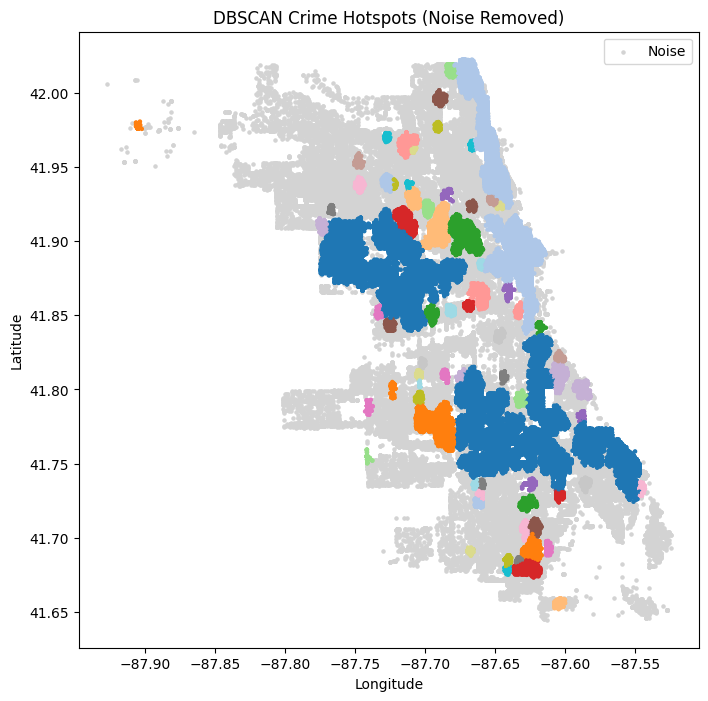

In [94]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,8))

# Noise
noise = df_db[df_db['dbscan_cluster'] == -1]
plt.scatter(
    noise['Longitude'], noise['Latitude'],
    c='lightgray', s=5, label='Noise'
)

# Hotspots
hotspots = df_db[df_db['dbscan_cluster'] != -1]
plt.scatter(
    hotspots['Longitude'], hotspots['Latitude'],
    c=hotspots['dbscan_cluster'],
    cmap='tab20', s=5
)

plt.title("DBSCAN Crime Hotspots (Noise Removed)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.show()


In [95]:
top_clusters = (
    df_db[df_db['dbscan_cluster'] != -1]
    .groupby('dbscan_cluster')
    .size()
    .sort_values(ascending=False)
    .head(10)
)

top_clusters


dbscan_cluster
3     15158
0     14583
6      8554
2      4932
4      4703
11     2190
18     1474
14     1155
1      1024
8       619
dtype: int64

In [96]:
df_hier = df_sample.sample(3_000, random_state=42)


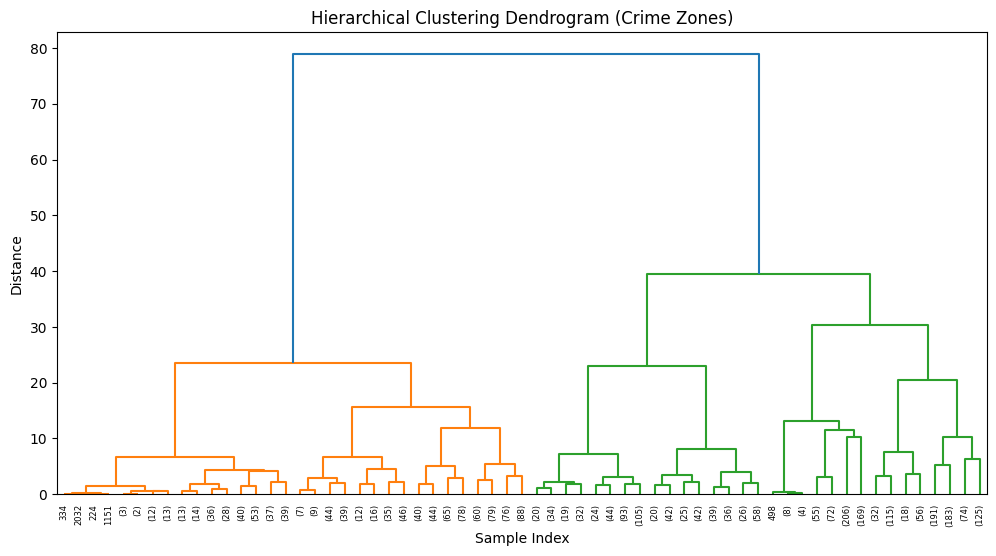

In [97]:
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

Z = df_hier[['Latitude', 'Longitude']].dropna()

Z_scaled = StandardScaler().fit_transform(Z)

Z = linkage(Z_scaled, method='ward')

plt.figure(figsize=(12,6))
dendrogram(Z, truncate_mode='level', p=5)
plt.title("Hierarchical Clustering Dendrogram (Crime Zones)")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.show()


## PCA

In [98]:
from sklearn.preprocessing import StandardScaler

In [99]:
pca_features = [
    'Latitude', 'Longitude',
    'Hour', 'Month', 'Day_enc', 'Is_Weekend',
    'location_freq',
    'Beat', 'District', 'Ward', 'Community Area'
]


In [100]:


X_PCA = df0[pca_features].dropna()

scaler = StandardScaler()
Xpca_scaled = scaler.fit_transform(X_PCA)


In [101]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3, random_state=42)
Xtrans_pca = pca.fit_transform(Xpca_scaled)


In [102]:
explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

for i, var in enumerate(cumulative_variance):
    print(f"PC{i+1}: {var:.2%}")


PC1: 39.92%
PC2: 50.67%
PC3: 60.90%


In [103]:
import pandas as pd

loadings = pd.DataFrame(
    pca.components_.T,
    index=pca_features,
    columns=['PC1','PC2','PC3']
)

loadings['importance'] = loadings.abs().sum(axis=1)

top5 = loadings.sort_values('importance', ascending=False).head(5)
top5


,PC1,PC2,PC3,importance
location_freq,-0.032794,0.633392,0.581324,1.247510
Is_Weekend,0.007713,0.586844,-0.414884,1.009441
Hour,-0.002960,-0.437621,0.506991,0.947572
Community Area,-0.362437,0.142986,0.180950,0.686373
Longitude,-0.331064,-0.135046,-0.183463,0.649572


## tnse

In [104]:
df_tsne = df0.sample(10_000, random_state=42)



In [105]:
tsne_features = [
    'Latitude', 'Longitude',
    'Hour', 'Month', 'Day_enc', 'Is_Weekend',
    'location_freq',
    'Arrest', 'Domestic',
    'primary_Theft',
    'primary_Battery',
    'primary_Assault',
    'primary_Robbery',
    'primary_Narcotics'
]


In [106]:
X_tsne = df_tsne[tsne_features].dropna()

X_tsne_scaled = scaler.fit_transform(X_tsne)

In [107]:
from sklearn.manifold import TSNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    max_iter=1000,
    random_state=42
)

X_embedded = tsne.fit_transform(X_tsne_scaled)

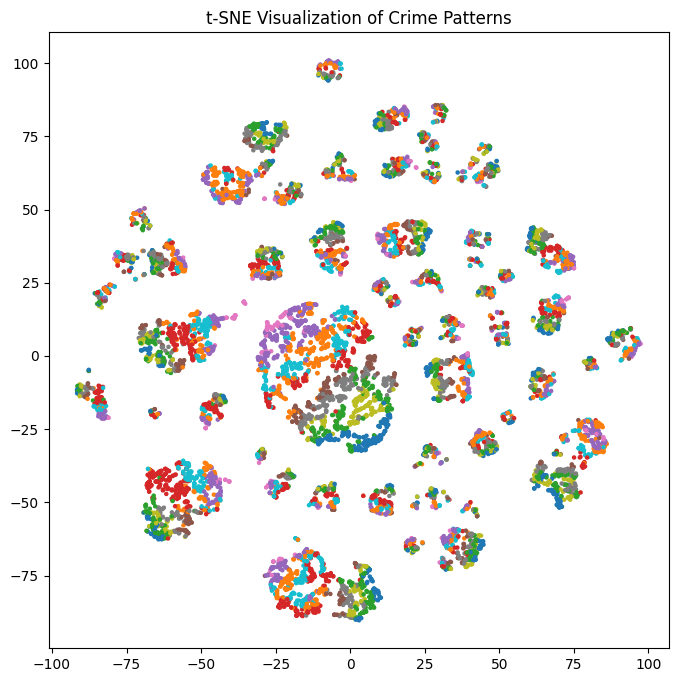

In [108]:
plt.figure(figsize=(8,8))
plt.scatter(
    X_embedded[:,0],
    X_embedded[:,1],
    c=df_tsne.loc[X_tsne.index, 'crime_zone'],
    cmap='tab10',
    s=5
)
plt.title("t-SNE Visualization of Crime Patterns")
plt.show()


In [109]:
pip install mlflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [110]:
''' import mlflow
import os

mlflow.set_tracking_uri("file:/content/mlruns")
mlflow.set_experiment("Chicago_Crime_Unsupervised")
'''


' import mlflow\nimport os\n\nmlflow.set_tracking_uri("file:/content/mlruns")\nmlflow.set_experiment("Chicago_Crime_Unsupervised")\n'

In [111]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [112]:
'''with mlflow.start_run(run_name="KMeans_Clustering"):
    algorithm = "KMeans"
    distance_metric = "euclidean"


 

   # Metrics
    inertia = kmeans.inertia_
    silhouette = silhouette_score(X_scaled, labels)

    # Log parameters
    mlflow.log_param("algorithm", algorithm)
    mlflow.log_param("k", k)
    mlflow.log_param("distance_metric", distance_metric)

    # Log metrics
    mlflow.log_metric("inertia", inertia)
    mlflow.log_metric("silhouette_score", silhouette)

    # Log model
    mlflow.sklearn.log_model(kmeans, "kmeans_model")'''



'with mlflow.start_run(run_name="KMeans_Clustering"):\n    algorithm = "KMeans"\n    distance_metric = "euclidean"\n\n\n\n\n   # Metrics\n    inertia = kmeans.inertia_\n    silhouette = silhouette_score(X_scaled, labels)\n\n    # Log parameters\n    mlflow.log_param("algorithm", algorithm)\n    mlflow.log_param("k", k)\n    mlflow.log_param("distance_metric", distance_metric)\n\n    # Log metrics\n    mlflow.log_metric("inertia", inertia)\n    mlflow.log_metric("silhouette_score", silhouette)\n\n    # Log model\n    mlflow.sklearn.log_model(kmeans, "kmeans_model")'

In [113]:
#!zip -r mlruns.zip C:\Padhma\GUVI\CCT\projects\patroliq-main\patroliq-main\mlruns


In [114]:
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri("http://127.0.0.1:5000")

print("MLflow URI:", mlflow.get_tracking_uri())

MLflow URI: http://127.0.0.1:5000


In [115]:
mlflow.set_experiment("KMeans_Clustering")

MlflowException: API request to http://127.0.0.1:5000/api/2.0/mlflow/experiments/get-by-name failed with exception HTTPConnectionPool(host='127.0.0.1', port=5000): Max retries exceeded with url: /api/2.0/mlflow/experiments/get-by-name?experiment_name=KMeans_Clustering (Caused by NewConnectionError("HTTPConnection(host='127.0.0.1', port=5000): Failed to establish a new connection: [WinError 10061] No connection could be made because the target machine actively refused it"))

In [ ]:
from sklearn.metrics import silhouette_score

sample_size = min(10000, len(X_scaled))

silhouette = silhouette_score(
    X_scaled,
    labels,
    sample_size=sample_size,
    random_state=42
)

print("Silhouette:", silhouette)

Silhouette: 0.28961808541209266


In [ ]:
import mlflow

mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("KMeans_Clustering")

print("Starting MLflow run...")

with mlflow.start_run(run_name="KMeans_Test"):

    print("1. Run created")

    mlflow.log_param("algorithm", "KMeans")
    mlflow.log_param("k", k)
    mlflow.log_param("distance_metric", "euclidean")

    print("2. Parameters logged")

    inertia = kmeans.inertia_
    #silhouette = silhouette_score(X_scaled, labels)

    #print("Inertia:", inertia)
    #print("Silhouette:", silhouette)

    mlflow.log_metric("inertia", inertia)
    print("3. Inertia logged")

    mlflow.log_metric("silhouette_score", silhouette)
    print("4. Silhouette logged")

     # Model
    print("5. Logging model...")

    mlflow.sklearn.log_model(
        kmeans,
        "kmeans_model"
    )

    print("6. Model logged")

print("MLflow test completed")

Starting MLflow run...
1. Run created
2. Parameters logged
3. Inertia logged
4. Silhouette logged
5. Logging model...


2026/09/08 16:12:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
c:\Users\rsrin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\mlflow\models\model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format.
  flavor.save_model(path=local_path, mlflow_model=mlflow_model, **kwargs)


6. Model logged
🏃 View run KMeans_Test at: http://127.0.0.1:5000/#/experiments/1/runs/58f948639f32442a9d3df8d7bb5f1889
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
MLflow test completed
